IMAGE COLORIZATION USING GAN

1: Check GPU and Install Dependencies

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
import os
from IPython.display import clear_output
import time

In [ ]:
print("="*60)
print("🔍 CHECKING GPU AVAILABILITY")
print("="*60)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Found: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   {gpu}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️  No GPU found. Training will be VERY slow on CPU!")
    print("💡 Enable GPU: Runtime > Change runtime type > GPU")

print(f"\n📦 TensorFlow Version: {tf.__version__}")
print("="*60)

🔍 CHECKING GPU AVAILABILITY


NameError: name 'tf' is not defined

2: Load and Preprocess Dataset

In [ ]:
print("\n🔄 LOADING CIFAR-10 DATASET...")
print("="*60)

# Load CIFAR-10
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"✅ Training samples: {x_train.shape[0]}")
print(f"✅ Test samples: {x_test.shape[0]}")
print(f"✅ Image shape: {x_train.shape[1:]}")



🔄 LOADING CIFAR-10 DATASET...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
✅ Training samples: 50000
✅ Test samples: 10000
✅ Image shape: (32, 32, 3)



🎨 Converting to grayscale...
✅ Grayscale shape: (50000, 32, 32, 1)
✅ Color shape: (50000, 32, 32, 3)


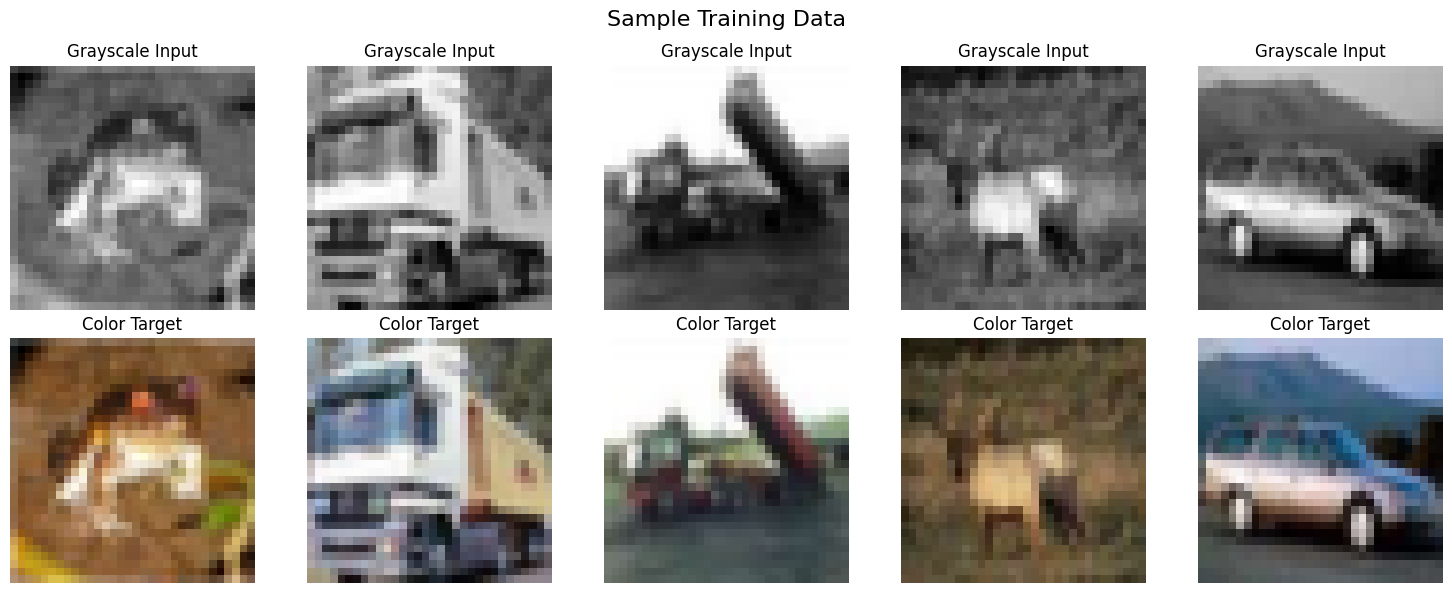

In [ ]:
# Convert to grayscale using luminosity method
print("\n🎨 Converting to grayscale...")
x_train_gray = np.dot(x_train[...,:3], [0.299, 0.587, 0.114])
x_train_gray = x_train_gray[..., np.newaxis]

x_test_gray = np.dot(x_test[...,:3], [0.299, 0.587, 0.114])
x_test_gray = x_test_gray[..., np.newaxis]

print(f"✅ Grayscale shape: {x_train_gray.shape}")
print(f"✅ Color shape: {x_train.shape}")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(x_train_gray[i].squeeze(), cmap='gray')
    axes[0, i].set_title('Grayscale Input')
    axes[0, i].axis('off')

    axes[1, i].imshow(x_train[i])
    axes[1, i].set_title('Color Target')
    axes[1, i].axis('off')

plt.suptitle('Sample Training Data', fontsize=16)
plt.tight_layout()
plt.show()

print("="*60)


3: Data Augmentation Pipeline

In [ ]:
print("\n🔧 SETTING UP DATA AUGMENTATION...")
print("="*60)

def augment_data(gray, color):
    """Apply random augmentations"""
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        gray = tf.image.flip_left_right(gray)
        color = tf.image.flip_left_right(color)

    # Random brightness adjustment (only to color)
    color = tf.image.random_brightness(color, max_delta=0.1)
    color = tf.clip_by_value(color, 0.0, 1.0)

    return gray, color



🔧 SETTING UP DATA AUGMENTATION...


In [ ]:
# Create TensorFlow datasets
BATCH_SIZE = 64
BUFFER_SIZE = 1000

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_gray, x_train))
train_dataset = train_dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test_gray, x_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"✅ Batch size: {BATCH_SIZE}")
print(f"✅ Batches per epoch: {len(x_train) // BATCH_SIZE}")
print(f"✅ Data augmentation: Enabled")
print("="*60)


✅ Batch size: 64
✅ Batches per epoch: 781
✅ Data augmentation: Enabled


4: Build Enhanced U-Net Generator

In [ ]:

print("\n🏗️  BUILDING ENHANCED U-NET GENERATOR...")
print("="*60)

def build_generator(input_shape=(32, 32, 1)):
    """
    Enhanced U-Net Generator with:
    - 4 encoder-decoder blocks (deeper than original)
    - Batch normalization for stability
    - Dropout for regularization
    - Skip connections for detail preservation
    """
    inputs = layers.Input(shape=input_shape, name='input_gray')

    # ===== ENCODER (Downsampling) =====
    # Block 1: 32x32 -> 16x16
    e1 = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    e1 = layers.LeakyReLU(alpha=0.2)(e1)

    # Block 2: 16x16 -> 8x8
    e2 = layers.Conv2D(128, 4, strides=2, padding='same')(e1)
    e2 = layers.BatchNormalization()(e2)
    e2 = layers.LeakyReLU(alpha=0.2)(e2)

    # Block 3: 8x8 -> 4x4
    e3 = layers.Conv2D(256, 4, strides=2, padding='same')(e2)
    e3 = layers.BatchNormalization()(e3)
    e3 = layers.LeakyReLU(alpha=0.2)(e3)

    # Block 4: 4x4 -> 2x2
    e4 = layers.Conv2D(512, 4, strides=2, padding='same')(e3)
    e4 = layers.BatchNormalization()(e4)
    e4 = layers.LeakyReLU(alpha=0.2)(e4)

    # ===== BOTTLENECK =====
    b = layers.Conv2D(512, 4, padding='same')(e4)
    b = layers.BatchNormalization()(b)
    b = layers.LeakyReLU(alpha=0.2)(b)

    # ===== DECODER (Upsampling with Skip Connections) =====
    # Block 1: 2x2 -> 4x4
    # Block 1: 2x2 -> 4x4
    d1 = layers.Conv2DTranspose(512, 4, strides=2, padding='same')(b)
    d1 = layers.BatchNormalization()(d1)
    d1 = layers.Dropout(0.5)(d1)
    d1 = layers.Concatenate()([d1, e3])  # correct skip
    d1 = layers.ReLU()(d1)

    # Block 2: 4x4 -> 8x8
    d2 = layers.Conv2DTranspose(256, 4, strides=2, padding='same')(d1)
    d2 = layers.BatchNormalization()(d2)
    d2 = layers.Dropout(0.5)(d2)
    d2 = layers.Concatenate()([d2, e2])
    d2 = layers.ReLU()(d2)

    # Block 3: 8x8 -> 16x16
    d3 = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(d2)
    d3 = layers.BatchNormalization()(d3)
    d3 = layers.Concatenate()([d3, e1])
    d3 = layers.ReLU()(d3)

    # Block 4: 16x16 -> 32x32
    d4 = layers.Conv2DTranspose(64, 4, strides=2, padding='same')(d3)
    d4 = layers.BatchNormalization()(d4)
    d4 = layers.ReLU()(d4)  # no skip here

    # ===== OUTPUT LAYER =====
    outputs = layers.Conv2D(3, 4, padding='same', activation='tanh')(d4)
    # Convert tanh [-1,1] to [0,1]
    outputs = layers.Lambda(lambda x: (x + 1) / 2)(outputs)

    model = Model(inputs=inputs, outputs=outputs, name='Generator')
    return model

# Build generator
generator = build_generator()
print("✅ Generator built successfully!")
print(f"   Total parameters: {generator.count_params():,}")
generator.summary()
print("="*60)



🏗️  BUILDING ENHANCED U-NET GENERATOR...
✅ Generator built successfully!
   Total parameters: 15,285,891


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_gray          │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │      1,088 │ input_gray[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 128) │    131,200 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 128) │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 4, 4, 256) │    524,544 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 256) │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 4, 4, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 2, 2, 512) │  2,097,664 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 2, 512) │      2,048 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 2, 2, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 2, 2, 512) │  4,194,816 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 2, 512) │      2,048 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 2, 2, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 4, 4, 512) │  4,194,816 │ leaky_re_lu_4[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 512) │      2,048 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4, 4, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 15,285,891 (58.31 MB)

 Trainable params: 15,281,155 (58.29 MB)

 Non-trainable params: 4,736 (18.50 KB)

 5: Build PatchGAN Discriminator




In [ ]:

print("\n🏗️  BUILDING PATCHGAN DISCRIMINATOR...")
print("="*60)

def build_discriminator(input_shape=(32, 32, 3)):
    """
    PatchGAN Discriminator that classifies if image patches are real/fake
    This is more effective than classifying the entire image
    """
    inputs = layers.Input(shape=input_shape, name='input_image')

    # Block 1: 32x32 -> 16x16
    d = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    d = layers.LeakyReLU(alpha=0.2)(d)

    # Block 2: 16x16 -> 8x8
    d = layers.Conv2D(128, 4, strides=2, padding='same')(d)
    d = layers.BatchNormalization()(d)
    d = layers.LeakyReLU(alpha=0.2)(d)

    # Block 3: 8x8 -> 4x4
    d = layers.Conv2D(256, 4, strides=2, padding='same')(d)
    d = layers.BatchNormalization()(d)
    d = layers.LeakyReLU(alpha=0.2)(d)

    # Block 4: 4x4 -> 4x4
    d = layers.Conv2D(512, 4, strides=1, padding='same')(d)
    d = layers.BatchNormalization()(d)
    d = layers.LeakyReLU(alpha=0.2)(d)

    # Output: 4x4 patch predictions
    outputs = layers.Conv2D(1, 4, strides=1, padding='same')(d)

    model = Model(inputs=inputs, outputs=outputs, name='Discriminator')
    return model

# Build discriminator
discriminator = build_discriminator()
print("✅ Discriminator built successfully!")
print(f"   Total parameters: {discriminator.count_params():,}")
discriminator.summary()
print("="*60)



🏗️  BUILDING PATCHGAN DISCRIMINATOR...
✅ Discriminator built successfully!
   Total parameters: 2,768,321


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 1)        │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,321 (10.56 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

6: Define Loss Functions and Optimizers



In [ ]:

print("\n⚙️  SETTING UP LOSS FUNCTIONS AND OPTIMIZERS...")
print("="*60)

# Loss function
bce_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    """Discriminator tries to classify real as 1 and fake as 0"""
    real_loss = bce_loss(tf.ones_like(real_output), real_output)
    fake_loss = bce_loss(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output, real_images, fake_images, lambda_l1=100):
    """
    Generator tries to:
    1. Fool discriminator (adversarial loss)
    2. Match real colors (L1 loss)
    """
    # Adversarial loss
    adv_loss = bce_loss(tf.ones_like(fake_output), fake_output)

    # L1 loss for color matching
    l1_loss = tf.reduce_mean(tf.abs(real_images - fake_images))

    # Combined loss
    total_loss = adv_loss + lambda_l1 * l1_loss

    return total_loss, adv_loss, l1_loss

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

print("✅ Loss functions defined")
print("✅ Optimizers configured")
print(f"   Learning rate: 2e-4")
print(f"   Lambda L1: 100")
print("="*60)




⚙️  SETTING UP LOSS FUNCTIONS AND OPTIMIZERS...
✅ Loss functions defined
✅ Optimizers configured
   Learning rate: 2e-4
   Lambda L1: 100


7: Training Step Function




In [ ]:

print("\n🔧 DEFINING TRAINING STEP...")
print("="*60)

@tf.function
def train_step(gray_images, real_images):
    """One training step for both generator and discriminator"""
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake colored images
        fake_images = generator(gray_images, training=True)

        # Discriminator predictions
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        # Calculate losses
        gen_total_loss, gen_adv_loss, gen_l1_loss = generator_loss(
            fake_output, real_images, fake_images, lambda_l1=100
        )
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculate gradients
    generator_gradients = gen_tape.gradient(
        gen_total_loss, generator.trainable_variables
    )
    discriminator_gradients = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    # Apply gradients
    generator_optimizer.apply_gradients(
        zip(generator_gradients, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(discriminator_gradients, discriminator.trainable_variables)
    )

    return gen_total_loss, gen_adv_loss, gen_l1_loss, disc_loss

print("✅ Training step defined with @tf.function for speed")
print("="*60)



🔧 DEFINING TRAINING STEP...
✅ Training step defined with @tf.function for speed


8: Training Configuration





In [ ]:

print("\n📋 TRAINING CONFIGURATION")
print("="*60)

# Training parameters
EPOCHS = 200  # Start with 200, increase to 500+ for better results
LAMBDA_L1 = 100
SAVE_INTERVAL = 20
DISPLAY_INTERVAL = 10

# Create directories
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('samples', exist_ok=True)

# Select sample images for monitoring
np.random.seed(42)
sample_idx = np.random.randint(0, x_test.shape[0], 6)
sample_gray = x_test_gray[sample_idx]
sample_color = x_test[sample_idx]

print(f"✅ Total epochs: {EPOCHS}")
print(f"✅ Batch size: {BATCH_SIZE}")
print(f"✅ Steps per epoch: {len(x_train) // BATCH_SIZE}")
print(f"✅ Total training steps: {EPOCHS * (len(x_train) // BATCH_SIZE)}")
print(f"✅ Save interval: Every {SAVE_INTERVAL} epochs")
print(f"✅ Display interval: Every {DISPLAY_INTERVAL} epochs")
print("="*60)

# Estimate training time
steps_per_epoch = len(x_train) // BATCH_SIZE
print(f"\n⏱️  ESTIMATED TRAINING TIME:")
if gpus:
    print(f"   With GPU (T4): ~{EPOCHS * 0.3:.0f} minutes ({EPOCHS * 0.3 / 60:.1f} hours)")
    print(f"   With GPU (V100): ~{EPOCHS * 0.15:.0f} minutes ({EPOCHS * 0.15 / 60:.1f} hours)")
else:
    print(f"   With CPU: ~{EPOCHS * 2:.0f} minutes ({EPOCHS * 2 / 60:.1f} hours) ⚠️ VERY SLOW!")
print("="*60)


📋 TRAINING CONFIGURATION
✅ Total epochs: 200
✅ Batch size: 64
✅ Steps per epoch: 781
✅ Total training steps: 156200
✅ Save interval: Every 20 epochs
✅ Display interval: Every 10 epochs

⏱️  ESTIMATED TRAINING TIME:
   With GPU (T4): ~60 minutes (1.0 hours)
   With GPU (V100): ~30 minutes (0.5 hours)


9: MAIN TRAINING LOOP


🚀 STARTING TRAINING...

Epoch 1/200 | Time: 81.94s
  Gen Total Loss:  9.3241
  Gen Adv Loss:    0.9195
  Gen L1 Loss:     0.0840
  Disc Loss:       1.2350
  Elapsed:         1.4 min
  ETA:             271.8 min


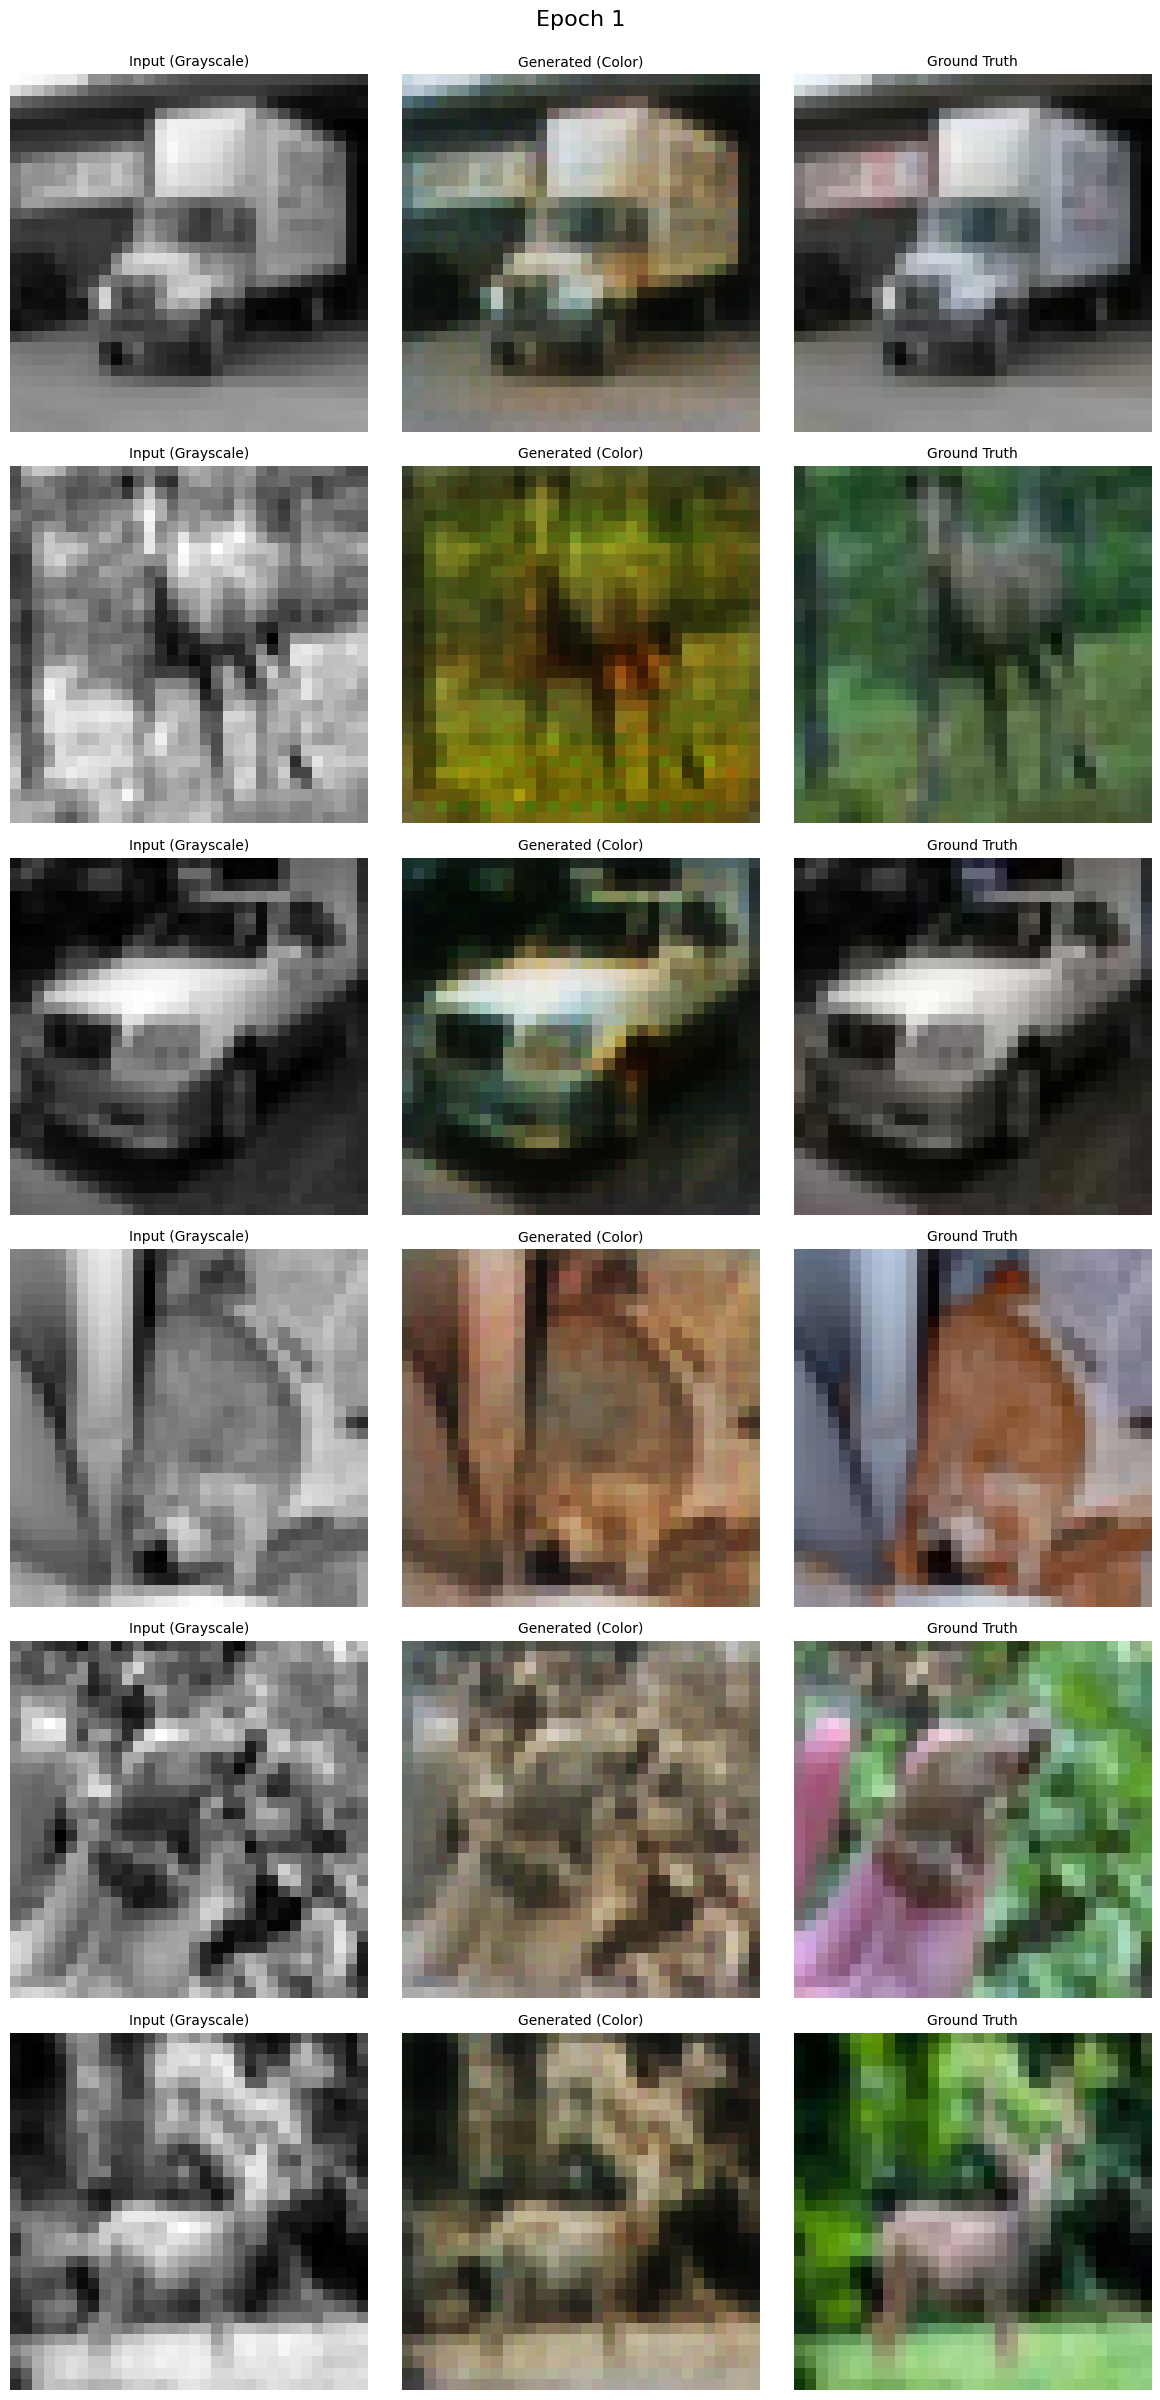

✅ Saved checkpoint and samples at epoch 1

Epoch 10/200 | Time: 81.90s
  Gen Total Loss:  9.1009
  Gen Adv Loss:    0.9827
  Gen L1 Loss:     0.0812
  Disc Loss:       1.1851
  Elapsed:         13.7 min
  ETA:             260.3 min

Epoch 20/200 | Time: 81.61s
  Gen Total Loss:  9.0029
  Gen Adv Loss:    1.0535
  Gen L1 Loss:     0.0795
  Disc Loss:       1.1513
  Elapsed:         28.4 min
  ETA:             255.3 min


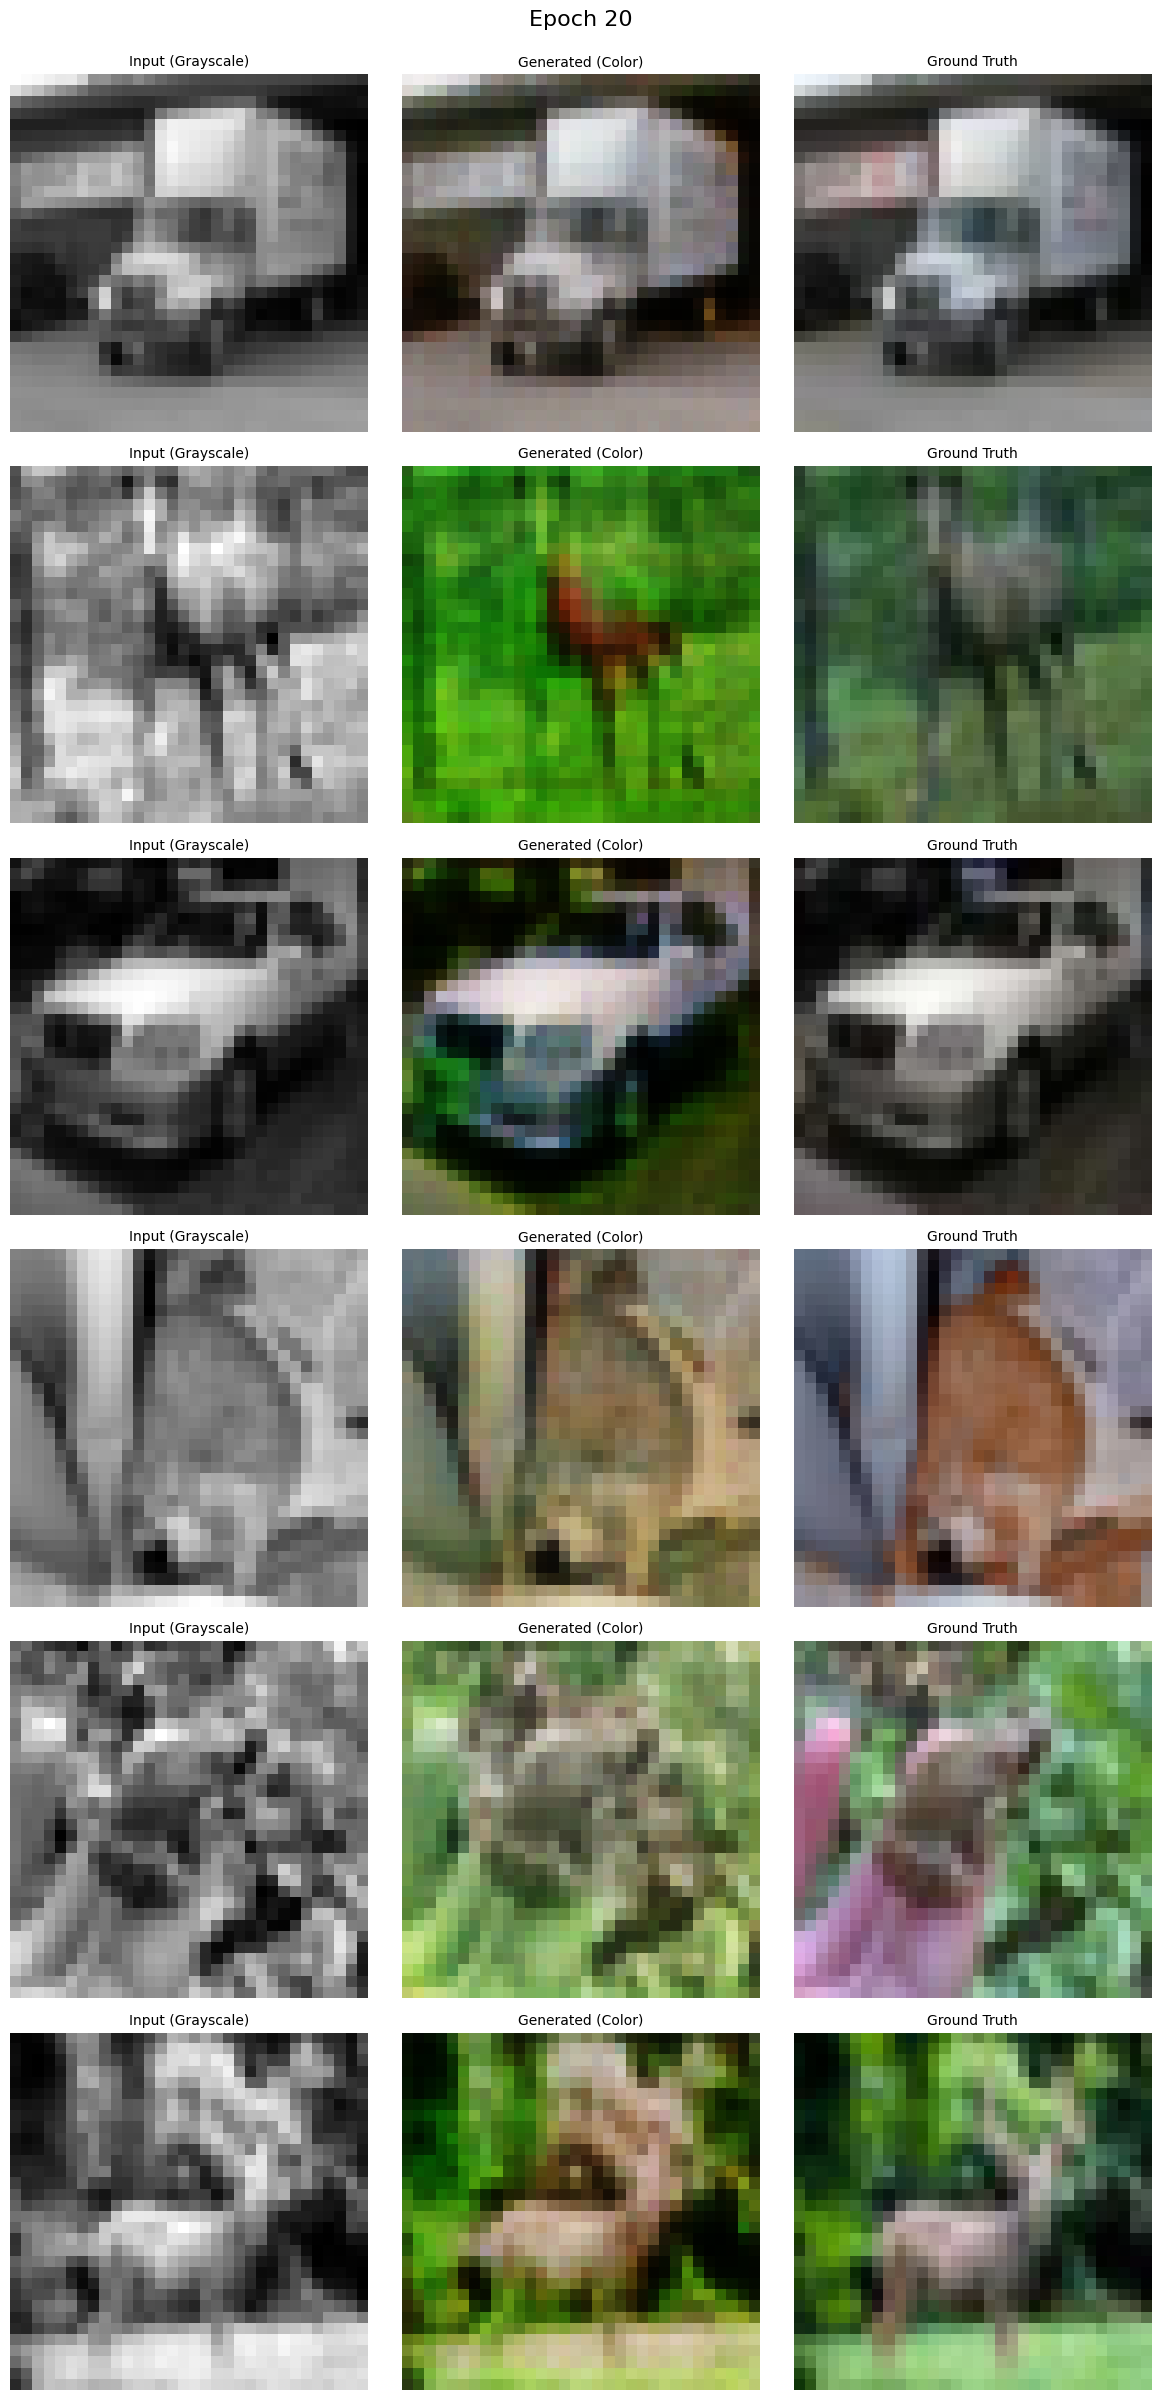

✅ Saved checkpoint and samples at epoch 20

Epoch 30/200 | Time: 141.91s
  Gen Total Loss:  9.0728
  Gen Adv Loss:    1.1963
  Gen L1 Loss:     0.0788
  Disc Loss:       1.0622
  Elapsed:         44.3 min
  ETA:             251.0 min

Epoch 40/200 | Time: 82.15s
  Gen Total Loss:  9.1116
  Gen Adv Loss:    1.3319
  Gen L1 Loss:     0.0778
  Disc Loss:       0.9773
  Elapsed:         58.0 min
  ETA:             232.0 min


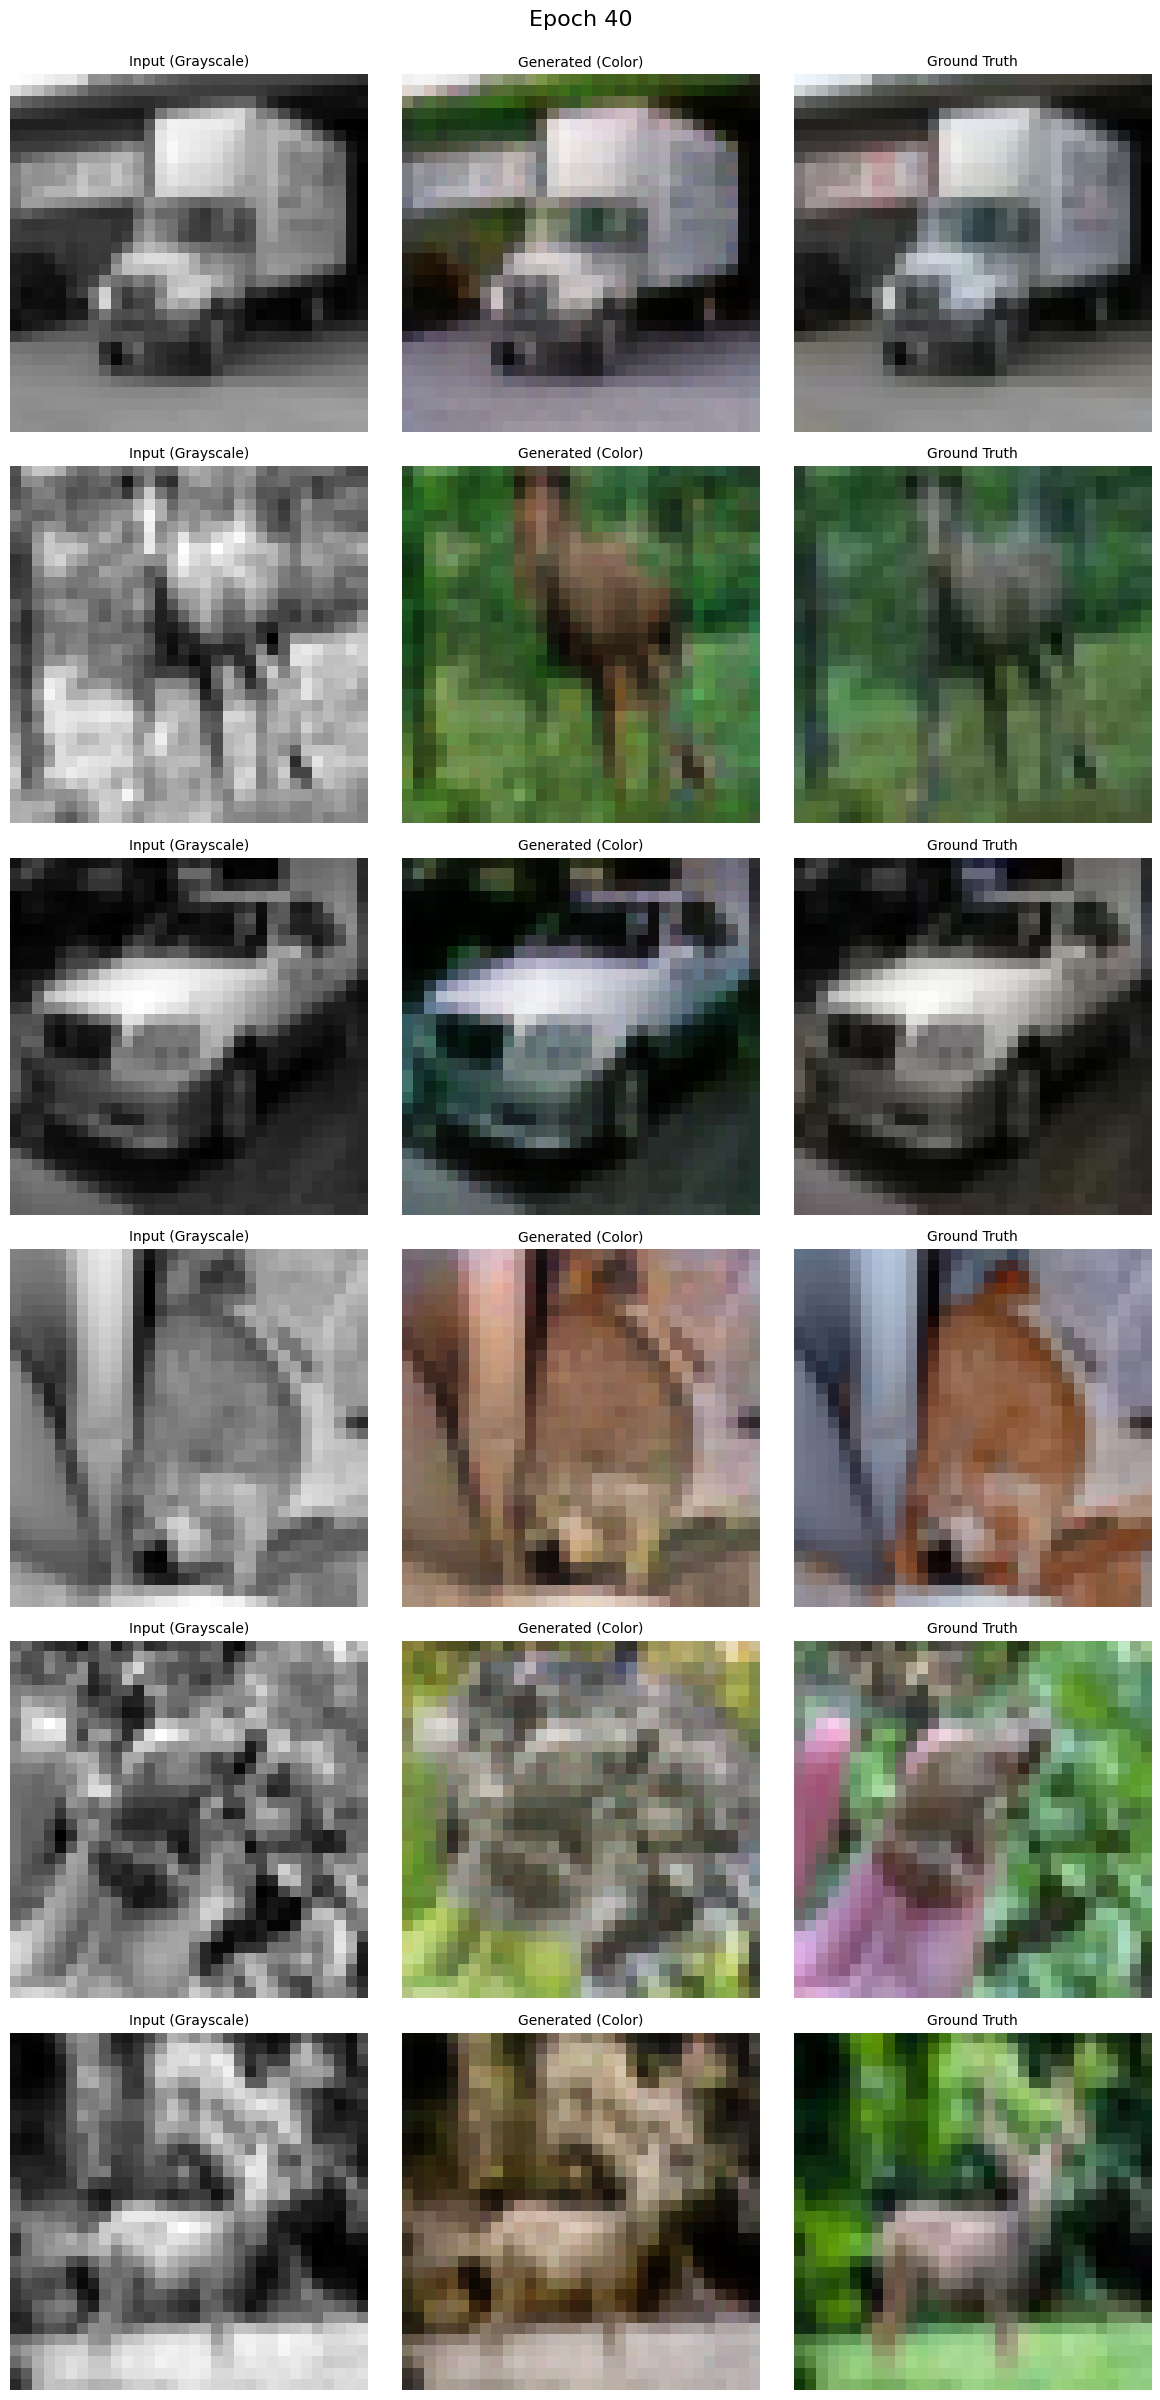

✅ Saved checkpoint and samples at epoch 40

Epoch 50/200 | Time: 82.16s
  Gen Total Loss:  9.2747
  Gen Adv Loss:    1.5350
  Gen L1 Loss:     0.0774
  Disc Loss:       0.8670
  Elapsed:         71.7 min
  ETA:             215.2 min

Epoch 60/200 | Time: 82.04s
  Gen Total Loss:  9.5052
  Gen Adv Loss:    1.7728
  Gen L1 Loss:     0.0773
  Disc Loss:       0.7798
  Elapsed:         85.4 min
  ETA:             199.2 min


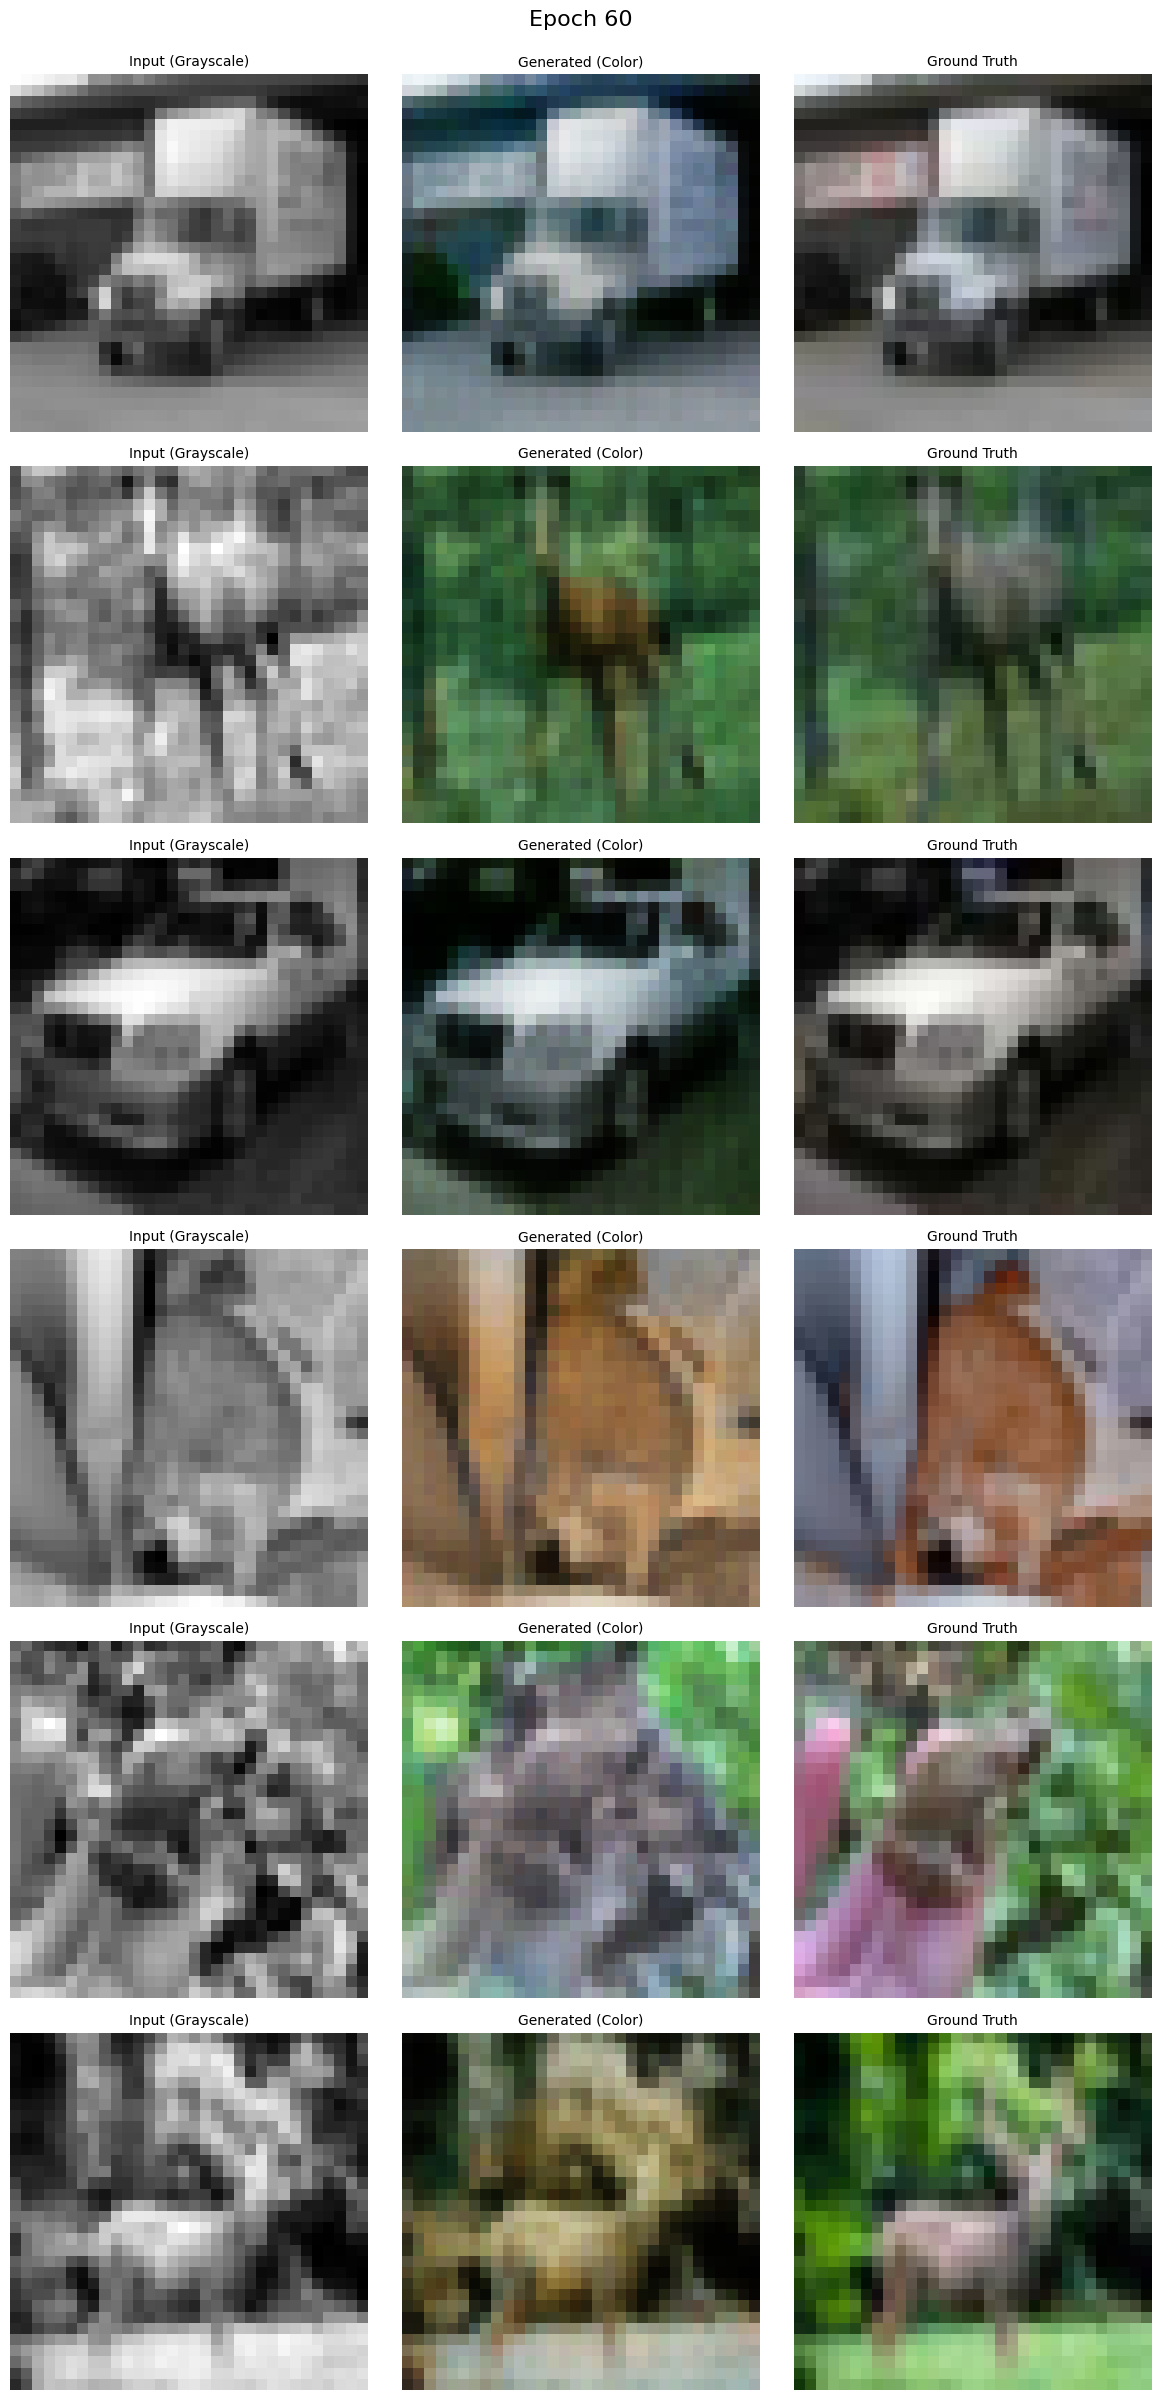

✅ Saved checkpoint and samples at epoch 60

Epoch 70/200 | Time: 81.92s
  Gen Total Loss:  9.6654
  Gen Adv Loss:    1.9602
  Gen L1 Loss:     0.0771
  Disc Loss:       0.7024
  Elapsed:         100.1 min
  ETA:             185.8 min

Epoch 80/200 | Time: 82.14s
  Gen Total Loss:  9.8692
  Gen Adv Loss:    2.1730
  Gen L1 Loss:     0.0770
  Disc Loss:       0.6483
  Elapsed:         113.8 min
  ETA:             170.6 min


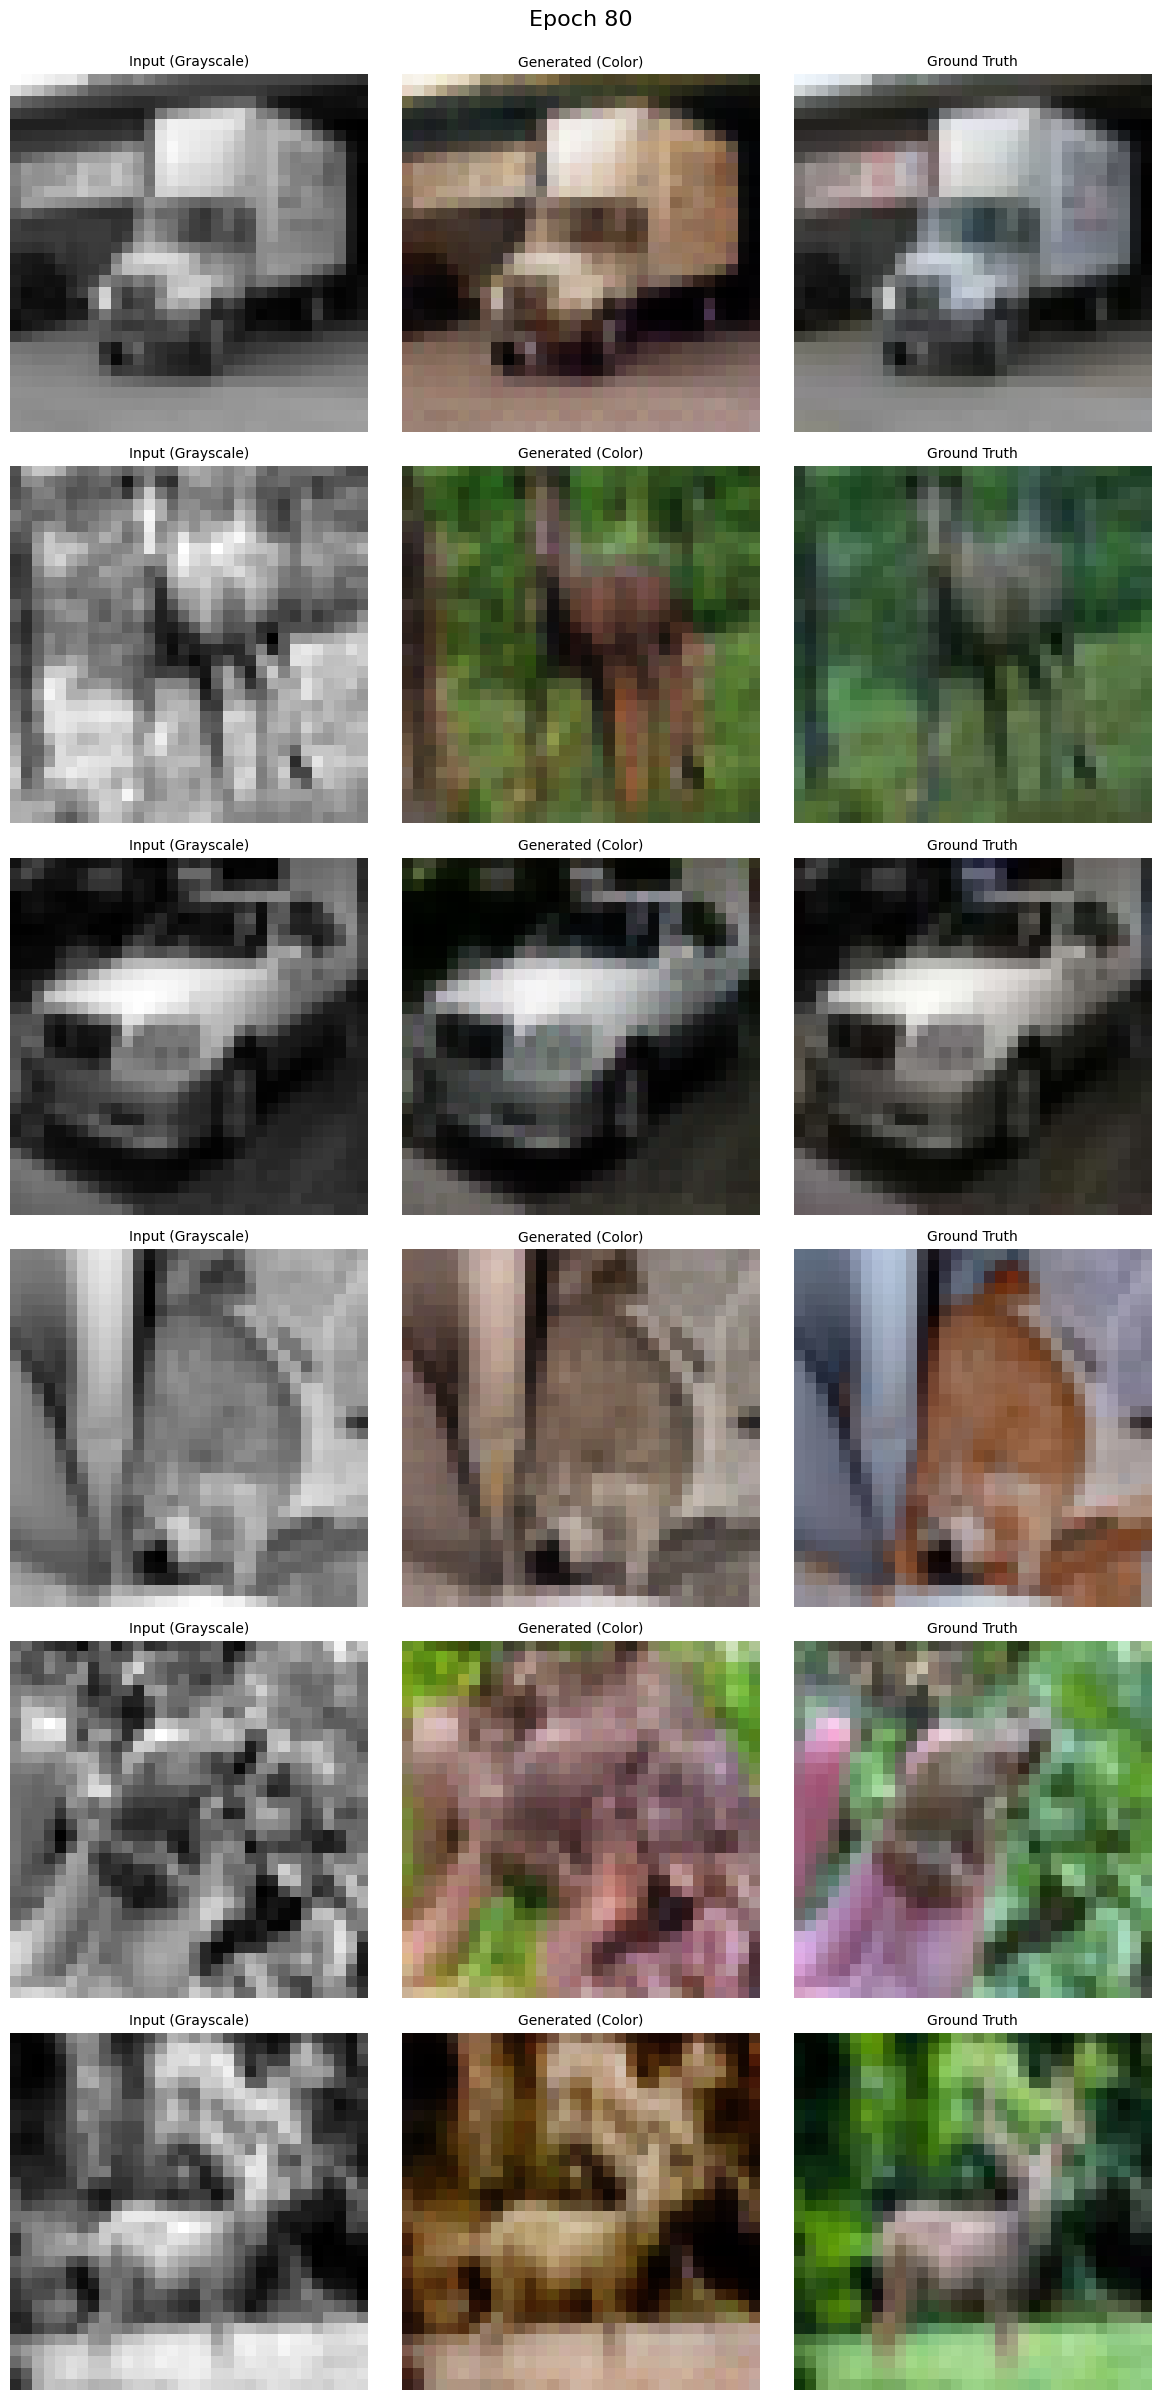

✅ Saved checkpoint and samples at epoch 80

Epoch 90/200 | Time: 82.40s
  Gen Total Loss:  10.0113
  Gen Adv Loss:    2.3556
  Gen L1 Loss:     0.0766
  Disc Loss:       0.5824
  Elapsed:         127.5 min
  ETA:             155.8 min

Epoch 100/200 | Time: 81.84s
  Gen Total Loss:  10.2104
  Gen Adv Loss:    2.5338
  Gen L1 Loss:     0.0768
  Disc Loss:       0.5227
  Elapsed:         142.2 min
  ETA:             142.2 min


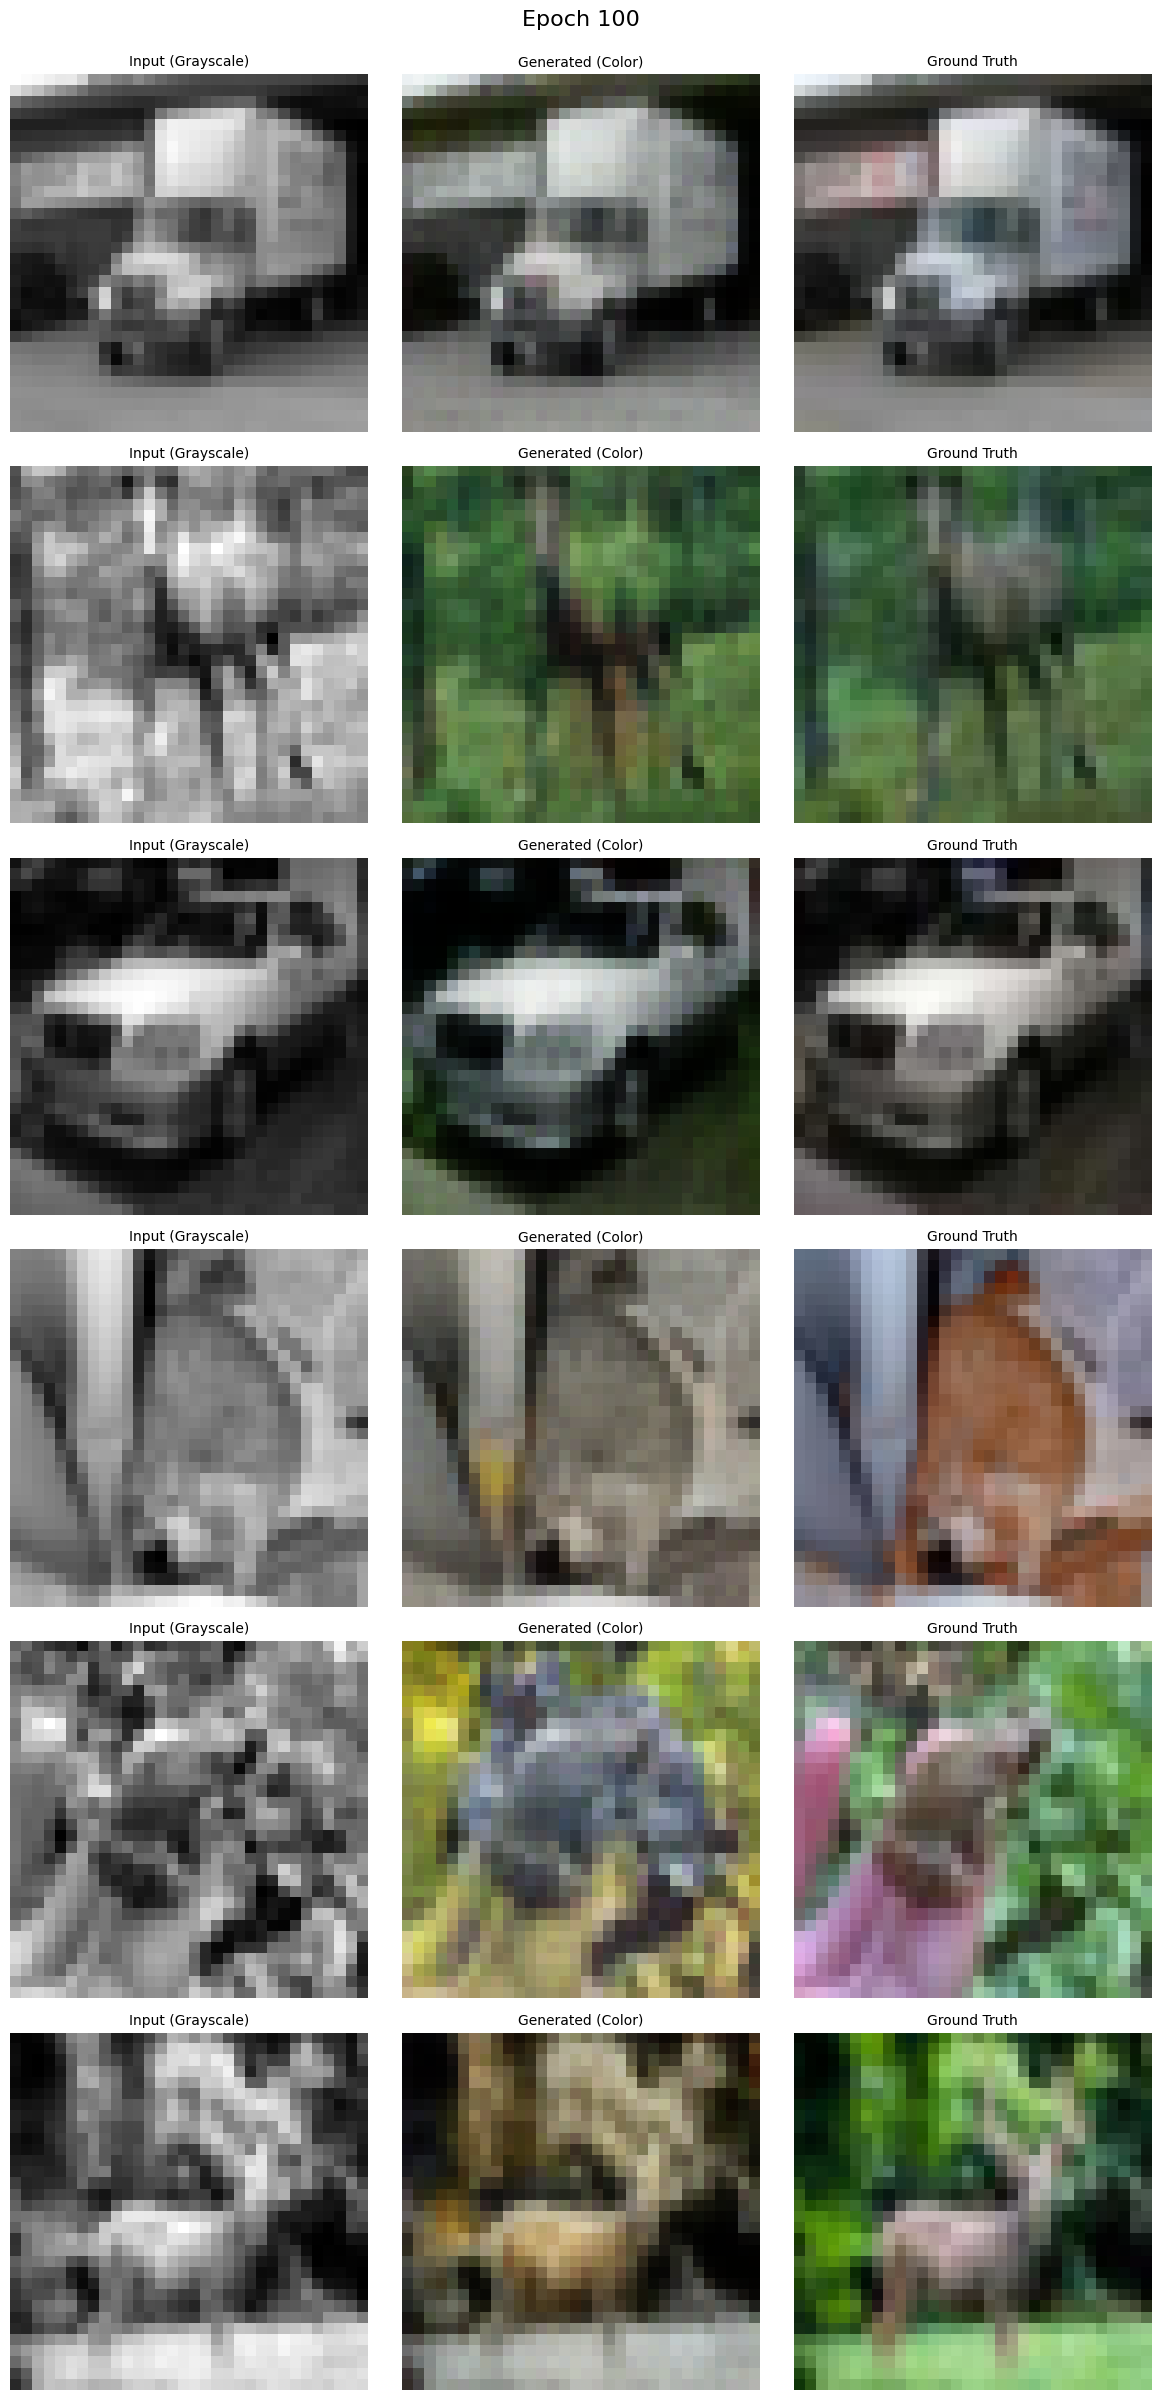

✅ Saved checkpoint and samples at epoch 100

Epoch 110/200 | Time: 82.14s
  Gen Total Loss:  10.3619
  Gen Adv Loss:    2.6910
  Gen L1 Loss:     0.0767
  Disc Loss:       0.4796
  Elapsed:         156.8 min
  ETA:             128.3 min

Epoch 120/200 | Time: 81.50s
  Gen Total Loss:  10.4862
  Gen Adv Loss:    2.8365
  Gen L1 Loss:     0.0765
  Disc Loss:       0.5002
  Elapsed:         170.5 min
  ETA:             113.7 min


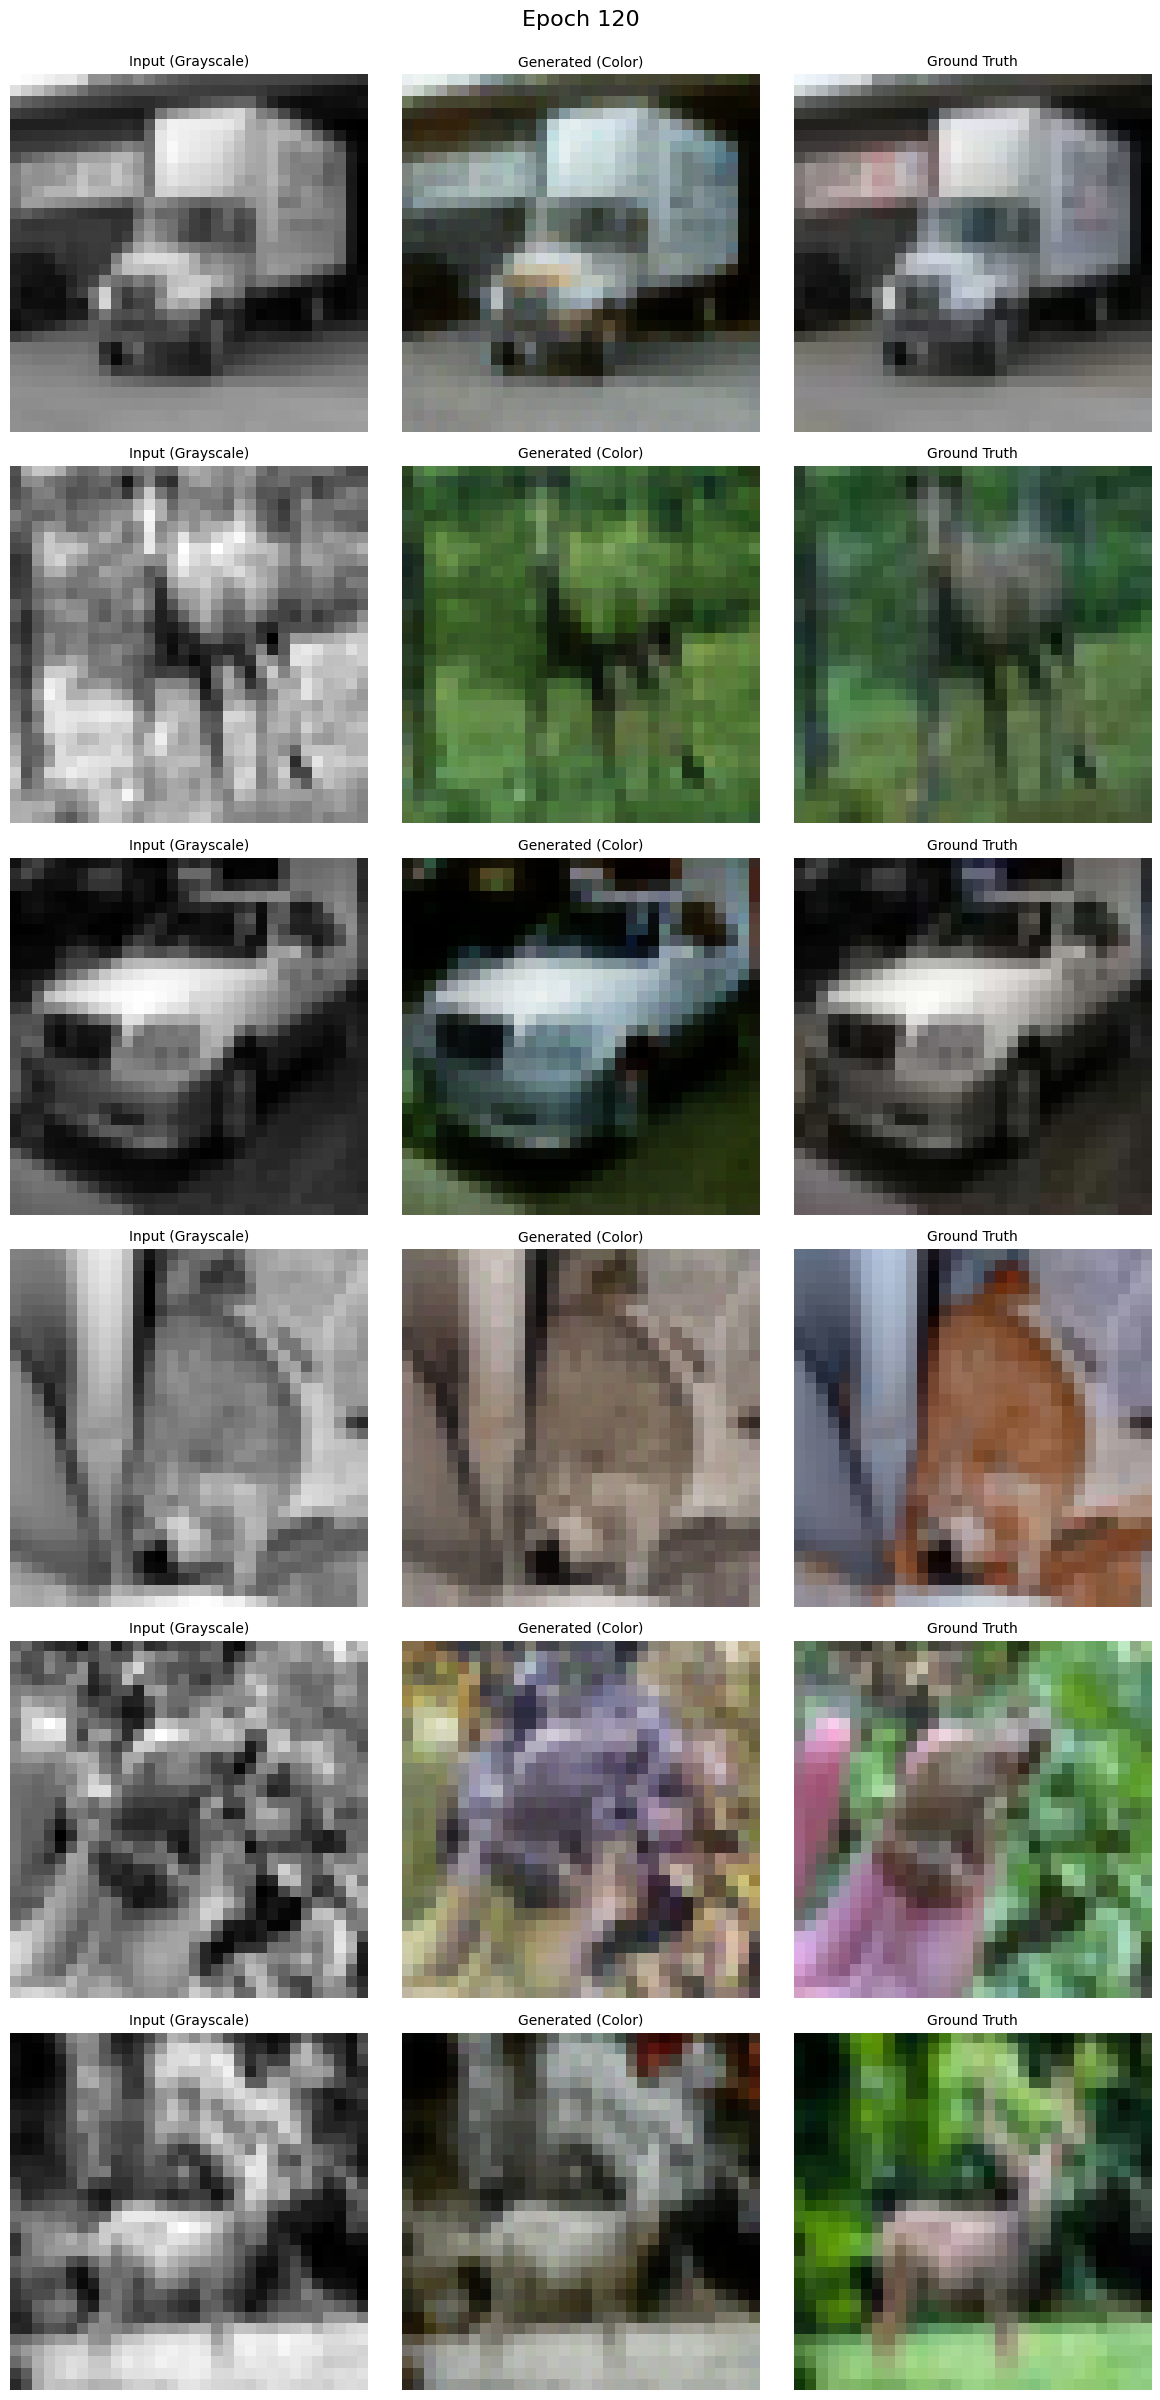

✅ Saved checkpoint and samples at epoch 120

Epoch 130/200 | Time: 81.52s
  Gen Total Loss:  10.5653
  Gen Adv Loss:    2.9138
  Gen L1 Loss:     0.0765
  Disc Loss:       0.4758
  Elapsed:         184.1 min
  ETA:             99.2 min

Epoch 140/200 | Time: 82.17s
  Gen Total Loss:  10.6209
  Gen Adv Loss:    2.9927
  Gen L1 Loss:     0.0763
  Disc Loss:       0.4502
  Elapsed:         197.8 min
  ETA:             84.8 min


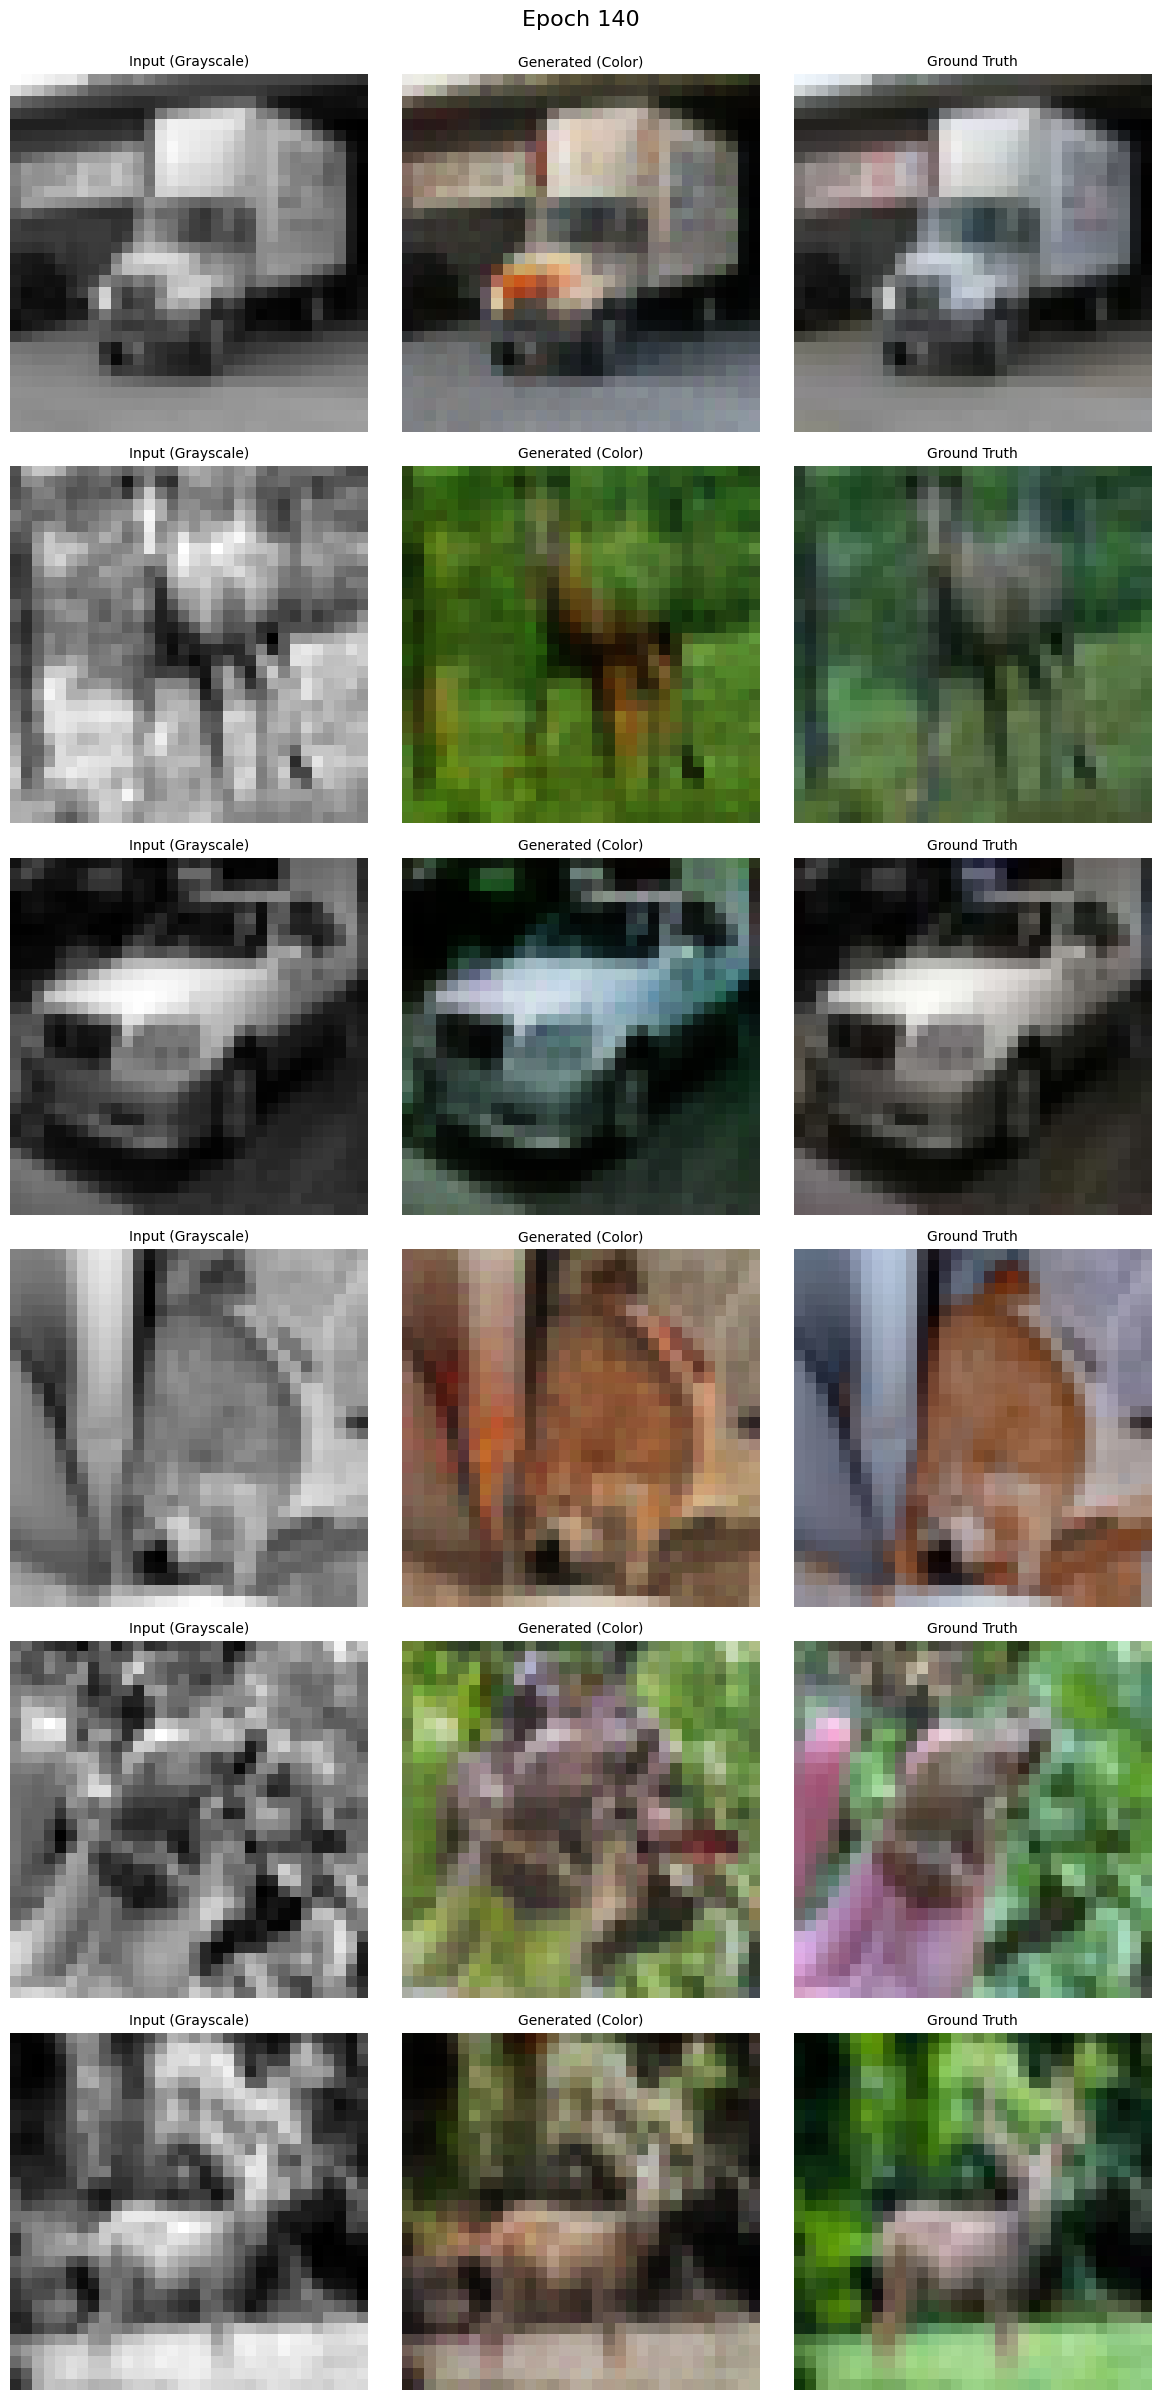

✅ Saved checkpoint and samples at epoch 140

Epoch 150/200 | Time: 82.33s
  Gen Total Loss:  10.8009
  Gen Adv Loss:    3.1967
  Gen L1 Loss:     0.0760
  Disc Loss:       0.4220
  Elapsed:         211.5 min
  ETA:             70.5 min


In [ ]:

print("\n🚀 STARTING TRAINING...")
print("="*60)

# Training history
history = {
    'gen_total_loss': [],
    'gen_adv_loss': [],
    'gen_l1_loss': [],
    'disc_loss': [],
    'epoch_times': []
}

# Training loop
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    epoch_gen_total_loss = []
    epoch_gen_adv_loss = []
    epoch_gen_l1_loss = []
    epoch_disc_loss = []

    # Training loop
    for step, (gray_batch, color_batch) in enumerate(train_dataset):
        gen_total, gen_adv, gen_l1, disc = train_step(gray_batch, color_batch)

        epoch_gen_total_loss.append(gen_total.numpy())
        epoch_gen_adv_loss.append(gen_adv.numpy())
        epoch_gen_l1_loss.append(gen_l1.numpy())
        epoch_disc_loss.append(disc.numpy())

    # Calculate average losses
    avg_gen_total = np.mean(epoch_gen_total_loss)
    avg_gen_adv = np.mean(epoch_gen_adv_loss)
    avg_gen_l1 = np.mean(epoch_gen_l1_loss)
    avg_disc = np.mean(epoch_disc_loss)

    epoch_time = time.time() - epoch_start

    # Store history
    history['gen_total_loss'].append(avg_gen_total)
    history['gen_adv_loss'].append(avg_gen_adv)
    history['gen_l1_loss'].append(avg_gen_l1)
    history['disc_loss'].append(avg_disc)
    history['epoch_times'].append(epoch_time)

    # Print progress
    if (epoch + 1) % DISPLAY_INTERVAL == 0 or epoch == 0:
        elapsed = time.time() - start_time
        eta = (elapsed / (epoch + 1)) * (EPOCHS - epoch - 1)

        print(f"\n{'='*60}")
        print(f"Epoch {epoch + 1}/{EPOCHS} | Time: {epoch_time:.2f}s")
        print(f"{'='*60}")
        print(f"  Gen Total Loss:  {avg_gen_total:.4f}")
        print(f"  Gen Adv Loss:    {avg_gen_adv:.4f}")
        print(f"  Gen L1 Loss:     {avg_gen_l1:.4f}")
        print(f"  Disc Loss:       {avg_disc:.4f}")
        print(f"  Elapsed:         {elapsed/60:.1f} min")
        print(f"  ETA:             {eta/60:.1f} min")

    # Generate and save sample images
    if (epoch + 1) % SAVE_INTERVAL == 0 or epoch == 0:
        generated_samples = generator.predict(sample_gray, verbose=0)

        fig, axes = plt.subplots(6, 3, figsize=(12, 24))
        for i in range(6):
            # Grayscale input
            axes[i, 0].imshow(sample_gray[i].squeeze(), cmap='gray')
            axes[i, 0].set_title('Input (Grayscale)', fontsize=10)
            axes[i, 0].axis('off')

            # Generated color
            axes[i, 1].imshow(np.clip(generated_samples[i], 0, 1))
            axes[i, 1].set_title('Generated (Color)', fontsize=10)
            axes[i, 1].axis('off')

            # Original color
            axes[i, 2].imshow(sample_color[i])
            axes[i, 2].set_title('Ground Truth', fontsize=10)
            axes[i, 2].axis('off')

        plt.suptitle(f'Epoch {epoch + 1}', fontsize=16, y=0.998)
        plt.tight_layout()
        plt.savefig(f'samples/epoch_{epoch+1:04d}.png', dpi=100, bbox_inches='tight')
        plt.show()

        # Save model checkpoints
        generator.save_weights(f'checkpoints/generator_epoch_{epoch+1:04d}.weights.h5')
        discriminator.save_weights(f'checkpoints/discriminator_epoch_{epoch+1:04d}.weights.h5')
        print(f"✅ Saved checkpoint and samples at epoch {epoch + 1}")

total_time = time.time() - start_time
print("\n" + "="*60)
print("🎉 TRAINING COMPLETED!")
print("="*60)
print(f"Total training time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"Average time per epoch: {np.mean(history['epoch_times']):.2f} seconds")
print("="*60)


In [ ]:
print("\n🚀 RESUMING TRAINING...")
print("="*60)

# ===============================
# 🔹 Load latest checkpoints
# ===============================
generator.load_weights('checkpoints/generator_epoch_140.weights.h5')
discriminator.load_weights('checkpoints/discriminator_epoch_140.weights.h5')

# ===============================
# 🔹 Resume training settings
# ===============================
start_epoch = 141      # next epoch to resume
EPOCHS = 200           # total epochs
DISPLAY_INTERVAL = 5   # print every 5 epochs
SAVE_INTERVAL = 5      # save samples and checkpoints every 5 epochs

# ===============================
# 🔹 Training history
# ===============================
history = {
    'gen_total_loss': [],
    'gen_adv_loss': [],
    'gen_l1_loss': [],
    'disc_loss': [],
    'epoch_times': []
}

# ===============================
# 🔹 Start training loop
# ===============================
start_time = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.time()

    # Epoch losses
    epoch_gen_total_loss = []
    epoch_gen_adv_loss = []
    epoch_gen_l1_loss = []
    epoch_disc_loss = []

    # ===============================
    # 🔹 Training over batches
    # ===============================
    for step, (gray_batch, color_batch) in enumerate(train_dataset):
        gen_total, gen_adv, gen_l1, disc = train_step(gray_batch, color_batch)

        epoch_gen_total_loss.append(gen_total.numpy())
        epoch_gen_adv_loss.append(gen_adv.numpy())
        epoch_gen_l1_loss.append(gen_l1.numpy())
        epoch_disc_loss.append(disc.numpy())

    # ===============================
    # 🔹 Calculate average losses
    # ===============================
    avg_gen_total = np.mean(epoch_gen_total_loss)
    avg_gen_adv = np.mean(epoch_gen_adv_loss)
    avg_gen_l1 = np.mean(epoch_gen_l1_loss)
    avg_disc = np.mean(epoch_disc_loss)

    epoch_time = time.time() - epoch_start

    # ===============================
    # 🔹 Store history
    # ===============================
    history['gen_total_loss'].append(avg_gen_total)
    history['gen_adv_loss'].append(avg_gen_adv)
    history['gen_l1_loss'].append(avg_gen_l1)
    history['disc_loss'].append(avg_disc)
    history['epoch_times'].append(epoch_time)

    # ===============================
    # 🔹 Print progress
    # ===============================
    if (epoch % DISPLAY_INTERVAL == 0) or (epoch == start_epoch):
        elapsed = time.time() - start_time
        eta = (elapsed / (epoch - start_epoch + 1)) * (EPOCHS - epoch)

        print(f"\n{'='*60}")
        print(f"Epoch {epoch}/{EPOCHS} | Time: {epoch_time:.2f}s")
        print(f"{'='*60}")
        print(f"  Gen Total Loss:  {avg_gen_total:.4f}")
        print(f"  Gen Adv Loss:    {avg_gen_adv:.4f}")
        print(f"  Gen L1 Loss:     {avg_gen_l1:.4f}")
        print(f"  Disc Loss:       {avg_disc:.4f}")
        print(f"  Elapsed:         {elapsed/60:.1f} min")
        print(f"  ETA:             {eta/60:.1f} min")

    # ===============================
    # 🔹 Generate & save sample images
    # ===============================
    if (epoch % SAVE_INTERVAL == 0) or (epoch == start_epoch):
        generated_samples = generator.predict(sample_gray, verbose=0)

        fig, axes = plt.subplots(6, 3, figsize=(12, 24))
        for i in range(6):
            # Grayscale input
            axes[i, 0].imshow(sample_gray[i].squeeze(), cmap='gray')
            axes[i, 0].set_title('Input (Grayscale)', fontsize=10)
            axes[i, 0].axis('off')

            # Generated color
            axes[i, 1].imshow(np.clip(generated_samples[i], 0, 1))
            axes[i, 1].set_title('Generated (Color)', fontsize=10)
            axes[i, 1].axis('off')

            # Ground truth
            axes[i, 2].imshow(sample_color[i])
            axes[i, 2].set_title('Ground Truth', fontsize=10)
            axes[i, 2].axis('off')

        plt.suptitle(f'Epoch {epoch}', fontsize=16, y=0.998)
        plt.tight_layout()
        plt.savefig(f'samples/epoch_{epoch:04d}.png', dpi=100, bbox_inches='tight')
        plt.show()

        # Save model checkpoints
        generator.save_weights(f'checkpoints/generator_epoch_{epoch:04d}.weights.h5')
        discriminator.save_weights(f'checkpoints/discriminator_epoch_{epoch:04d}.weights.h5')
        print(f"✅ Saved checkpoint and samples at epoch {epoch}")

# ===============================
# 🔹 Training finished
# ===============================
total_time = time.time() - start_time
print("\n" + "="*60)
print("🎉 TRAINING COMPLETED!")
print("="*60)
print(f"Total training time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"Average time per epoch: {np.mean(history['epoch_times']):.2f} seconds")
print("="*60)

10: Visualize Training History

In [ ]:

print("\n📊 PLOTTING TRAINING HISTORY...")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Generator Total Loss
axes[0, 0].plot(history['gen_total_loss'], linewidth=2, color='#2E86AB')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Generator Total Loss', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Generator Adversarial Loss
axes[0, 1].plot(history['gen_adv_loss'], linewidth=2, color='#06A77D')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Generator Adversarial Loss', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Generator L1 Loss
axes[1, 0].plot(history['gen_l1_loss'], linewidth=2, color='#F18F01')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].set_title('Generator L1 Loss (Color Matching)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Discriminator Loss
axes[1, 1].plot(history['disc_loss'], linewidth=2, color='#C73E1D')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Loss', fontsize=12)
axes[1, 1].set_title('Discriminator Loss', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history plotted and saved")
print("="*60)


11: Test on Random Images

In [ ]:

print("\n🎨 TESTING ON RANDOM IMAGES...")
print("="*60)

# Test on random images
n_test = 10
test_idx = np.random.randint(0, x_test.shape[0], n_test)
test_gray = x_test_gray[test_idx]
test_color = x_test[test_idx]

# Generate colorized images
generated_color = generator.predict(test_gray, verbose=0)

# Display results
fig, axes = plt.subplots(n_test, 3, figsize=(12, 4 * n_test))

for i in range(n_test):
    # Grayscale input
    axes[i, 0].imshow(test_gray[i].squeeze(), cmap='gray')
    axes[i, 0].set_title('Input (Grayscale)', fontsize=12)
    axes[i, 0].axis('off')

    # Generated color
    axes[i, 1].imshow(np.clip(generated_color[i], 0, 1))
    axes[i, 1].set_title('Generated (Colorized)', fontsize=12)
    axes[i, 1].axis('off')

    # Original color
    axes[i, 2].imshow(test_color[i])
    axes[i, 2].set_title('Original (Ground Truth)', fontsize=12)
    axes[i, 2].axis('off')

plt.suptitle('Final Colorization Results', fontsize=18, fontweight='bold', y=0.999)
plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Test results generated and saved")
print("="*60)


12: Save Final Models

In [ ]:

print("\n💾 SAVING FINAL MODELS...")
print("="*60)

# Save complete models
generator.save('colorization_generator_final.h5')
discriminator.save('colorization_discriminator_final.h5')

# Also save as SavedModel format (more portable)
generator.save('generator_saved_model')
discriminator.save('discriminator_saved_model')

print("✅ Models saved successfully!")
print("   - Generator (H5): colorization_generator_final.h5")
print("   - Discriminator (H5): colorization_discriminator_final.h5")
print("   - Generator (SavedModel): generator_saved_model/")
print("   - Discriminator (SavedModel): discriminator_saved_model/")
print("="*60)

13: Download Files from Colab (Optional)





In [ ]:

print("\n📥 DOWNLOAD FILES FROM COLAB")
print("="*60)
print("To download files, run these commands:")
print()
print("# Download trained models")
print("from google.colab import files")
print("files.download('colorization_generator_final.h5')")
print("files.download('training_history.png')")
print("files.download('final_results.png')")
print()
print("# Or zip everything and download")
print("!zip -r colorization_results.zip checkpoints samples *.png *.h5")
print("files.download('colorization_results.zip')")
print("="*60)

14: Load and Use Model Later

In [ ]:
#========================================
# CELL 14: Load and Use Model Later
# ========================================
print("\n🔄 TO LOAD MODEL LATER (for inference):")
print("="*60)
print("""
# Load the trained generator
from tensorflow.keras.models import load_model
generator = load_model('colorization_generator_final.h5')

# Use it to colorize new images
# (images should be grayscale, shape (N, 32, 32, 1), normalized to [0,1])
colorized = generator.predict(your_grayscale_images)
""")
print("="*60)